<a href="https://colab.research.google.com/github/Kaushika-M/EDA-Feature-Engineering/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_excel("Dataset for Data Analytics.xlsx")

In [7]:
print(df.shape)

(1200, 14)


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [9]:
print(df.describe())

                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


In [10]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [11]:
df['CouponCode']=df['CouponCode'].fillna('Not Known')

In [12]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
1195    False
1196    False
1197    False
1198    False
1199    False
Length: 1200, dtype: bool


In [13]:
num_cols=["Quantity","UnitPrice","ItemsInCart","TotalPrice"]
for i in num_cols:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)

  iqr=q3-q1

  lower=q1-1.5*iqr
  upper=q3+1.5*iqr

  df = df[(df[i] >= lower) & (df[i] <= upper)]

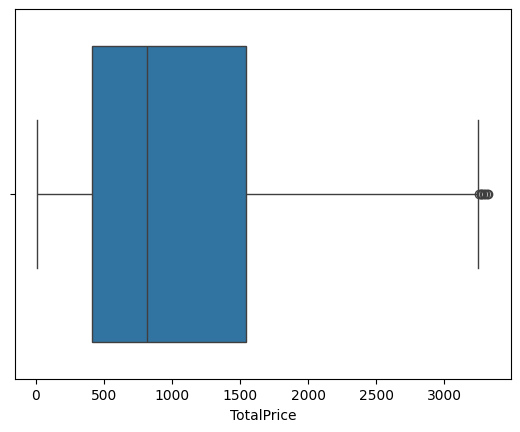

In [20]:
sns.boxplot(x=df["TotalPrice"])
plt.show()

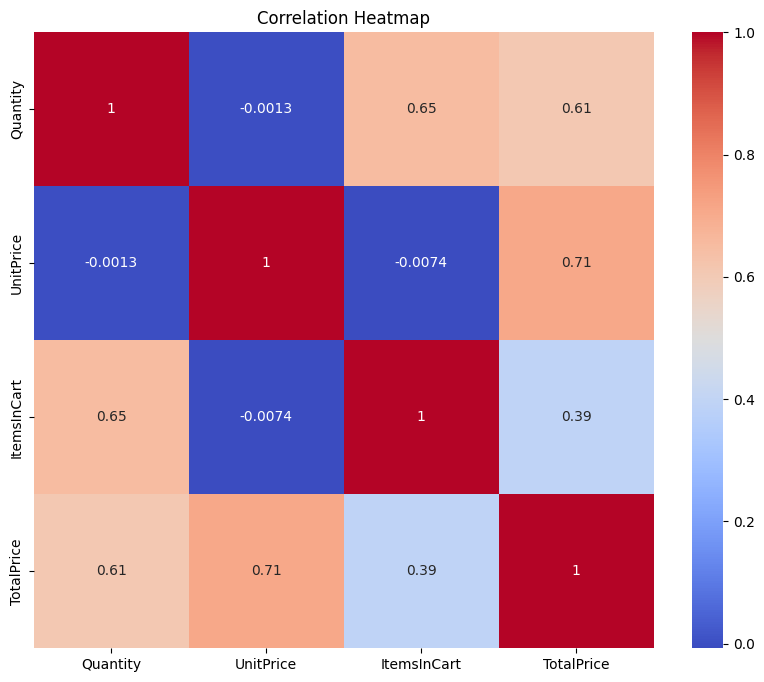

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

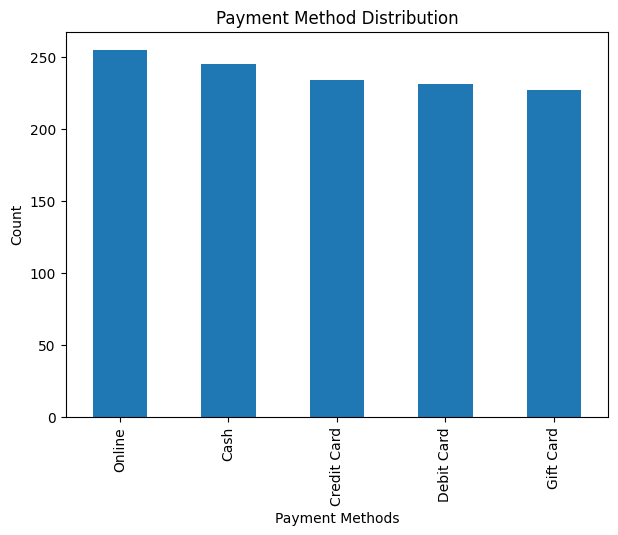

In [15]:
plt.figure(figsize=(7,5))

df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Methods")
plt.ylabel("Count")

plt.show()

In [16]:
df["TotalValue"]=df["Quantity"]*df["UnitPrice"]
df["AvgCart"]=df["TotalPrice"]/df["ItemsInCart"]
df['CouponUsed']=np.where(df['CouponCode']=="Not Known",0,1)

In [21]:
df.to_csv("Cleaned_Dataset.csv", index=False)